In [111]:
import yaml
from typing import Literal, Annotated
from pydantic import BaseModel
import openai

from shopping_assistant.env import load_env

from langgraph.graph import StateGraph, add_messages, START, END
from langchain_community.adapters.openai import convert_message_to_dict as convert_lc_message_to_openai_dict

from agents import Agent, function_tool, FunctionTool, Runner, set_tracing_disabled

## Env Vars

In [112]:
load_env()
set_tracing_disabled(True)

## Load config

In [113]:
with open("config.yml", "r") as f:
    CONFIG = yaml.safe_load(f)

## Initialize openai client

In [114]:
openai_client = openai.OpenAI()

## LangGraph Workflow

### State

In [115]:
def add_messages_openai(messages_l, messages_r):

    messages_comb = add_messages(messages_l, messages_r)

    for idx, lc_msg in enumerate(messages_comb):
        try:
            messages_comb[idx] = convert_lc_message_to_openai_dict(lc_msg)
        except TypeError:
            pass

    return messages_comb

In [116]:
class State(BaseModel):
    messages: Annotated[list, add_messages_openai]

### Router Agent

In [117]:
downstream_routes_list = [d["name"] for d in CONFIG["agents"]["router"]["downstream_routes"]]

In [118]:

class DownstreamRoutesAgentResponse(BaseModel):
    route: Literal[*downstream_routes_list]

In [119]:
class RouterAgent:

    def __init__(self, config):
        self.config = config

    def run(self, state: State) -> Literal[*downstream_routes_list]:
        input_messages = [
            {"role": "system", "content": self.config['prompts']['system_prompt']},
            *state.messages[:-1],
            {"role": "user", "content": f"Route based on this message: {state.messages[-1]['content']}"}
        ]

        response = openai_client.responses.parse(
            model=self.config["llm"],
            input=input_messages,
            text_format=DownstreamRoutesAgentResponse
        )

        return response.output_parsed.route

        

In [120]:
state = State(messages=[{"role": "user", "content": "I want to buy a new laptop."}])

router_agent = RouterAgent(config=CONFIG["agents"]["router"])

router_agent.run(state)

'shopping_actions'

### Shopping Actions Agent

In [85]:
from collections import Counter


class Cart:
    def __init__(self, user_id: str):
        self.user_id = user_id
        self.items = Counter()

    def add_item(self, item_id: str, quantity: int):
        self.items[item_id] += quantity
        return self

    def remove_item(self, item_id: str, quantity: int):
        cur_qty = self.items.get(item_id, 0)
        if cur_qty < quantity:
            raise ValueError("Not enough quantity in cart")
        if cur_qty == quantity:
            return self.empty_item(item_id)
    
        self.items[item_id] -= quantity
        return self

    def empty_cart(self):
        self.items.clear()
        return self

    def empty_item(self, item_id: str):
        cur_qty = self.items.get(item_id, 0)
        if cur_qty == 0:
            raise ValueError("Item not found in cart")
            
        self.items.pop(item_id)
        return self

    def view_cart(self):
        return dict(self.items)

    def __repr__(self) -> str:
        return f'Cart({self.view_cart()})'

In [31]:
cart = Cart('123')

print(cart.view_cart())

cart.add_item('item_1', quantity=1)
print(cart.view_cart())

cart.remove_item('item_1', quantity=1)
print(cart.view_cart())

cart.empty_cart()
print(cart.view_cart())

{}
{'item_1': 1}
{}
{}


In [60]:
import nest_asyncio
nest_asyncio.apply()

In [95]:
class ShoppingActionsAgent:

    def __init__(self, config, cart: Cart):
        self.config = config
        self.cart = cart
        self.tool_store = self._get_tool_store()
        self.agent_actions = self._define_agent_actions(self.tool_store)
        self.action_list = self._get_action_list(self.agent_actions)
        self.action_summary = self._get_action_summary(self.agent_actions)
        self.action_detailed = self._get_action_detailed(self.action_summary, self.agent_actions)
        self.system_prompt = self._build_system_prompt(self.action_list, self.action_summary, self.action_detailed)
        self.agent = self._build_agent(self.system_prompt)

    def _get_tool_store(self) -> dict[str, list[FunctionTool]]:
        return {
            "cart": self._get_cart_action_tools(),
        } 

    @property
    def tools(self):
        tools = []
        for action, tool_lst in self.tool_store.items():
            tools += tool_lst
        
        return tools

    def _get_cart_action_tools(self) -> list[FunctionTool]:

        @function_tool
        def add_to_cart(
            item_id: Annotated[str, "item_id"],
            quantity: Annotated[int, "quantity"] = 1
        ) -> dict:
            """Add an item to user's cart"""
            try:
                self.cart.add_item(item_id, quantity)
            except Exception as e:
                return "Error updating cart: " + str(e)
            
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        @function_tool
        def remove_from_cart(item_id: str, quantity: Annotated[int, "quantity"]) -> dict:
            """Remove an item from user's cart. Returns the updated cart."""
            self.cart.remove_item(item_id, quantity)
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        @function_tool
        def view_cart() -> dict:
            """View user's cart"""
            return self.cart.view_cart()

        @function_tool
        def empty_cart() -> str:
            """Empty user's cart"""
            self.cart.empty_cart()
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        @function_tool
        def empty_item(item_id: str) -> str:
            """Empty a specific item from user's cart"""
            self.cart.empty_item(item_id)
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        return [
            add_to_cart,
            remove_from_cart,
            view_cart,
            empty_cart,
            empty_item,
        ]

    def _define_agent_actions(self, tool_store: dict[str, list[FunctionTool]]) -> dict:
        agent_actions = {
            "cart": {
                "summary": "Manage your shopping cart (add or remove items, view cart)",
                "tools": tool_store["cart"],
            }
        }

        return agent_actions

    def _get_action_list(self, agent_actions: dict) -> list[str]:
        return list(agent_actions.keys())

    def _get_action_summary(self, agent_actions: dict) -> dict[str, str]:
        action_summary = {
            action_type: f"{idx + 1}. Action=`{action_type}`: {info['summary']}"
            for idx, (action_type, info) in enumerate(agent_actions.items())
        }

        return action_summary

    def _get_action_detailed(self, action_summary: dict[str, str], agent_actions: dict) -> dict[str, str]:
        action_detailed = ""
        for idx, (action_type, info) in enumerate(agent_actions.items()):
            action_detailed += action_summary[action_type] + "\n"
            for tool in info["tools"]:
                action_detailed += f"- Tool=`{tool.name}`: {tool.description}" + "\n"

        return action_detailed

    def _build_system_prompt(self, action_list: list[str], action_summary: dict[str, str], action_detailed: dict[str, str]) -> str:
        system_prompt = self.config['prompts']['system_prompt'].format(
            action_list=action_list,
            action_summary='\n'.join(action_summary.values()),
            action_detailed=action_detailed,
        )

        return system_prompt

    def _build_agent(self, system_prompt: str) -> Agent:
        return Agent(
            name='shopping_actions_agent',
            instructions=system_prompt,
            tools=self.tools,
            model=self.config['llm'],
        )
            
    async def run(self, state: State):
        response = await Runner.run(self.agent, state.messages)
        new_state = State(
            messages=[{"role": "assistant", "content": response.final_output}]
        )
        return new_state



In [96]:
state = State(
    messages=[
        {"role": "user", "content": "Can you please add item_123 to the cart?"}
    ]
)

In [97]:
cart = Cart(user_id="u_123")
shopping_actions_agent = ShoppingActionsAgent(CONFIG['agents']['shopping_actions'], cart)
new_state = await shopping_actions_agent.run(state)

In [100]:
print(new_state.messages[-1]['role'].upper(), ':', new_state.messages[-1]['content'])

ASSISTANT : Item `item_123` has been successfully added to your cart. Your current cart now contains: {'item_123': 1}.


In [101]:
cart

Cart({'item_123': 1})

In [102]:
class CustomerServiceAgent:
    def __init__(self, config, openai_client: openai.OpenAI):
        self.config = config
        self.openai_client = openai_client

    def run(self, state: State) -> State:
        input_messages = [
            {"role": "system", "content": self.config["prompts"]["system_prompt"]},
            *state.messages[:-1],
            {"role": "user", "content": state.messages[-1]["content"]}
        ]

        responses_obj = self.openai_client.chat.completions.create(
            model=self.config["llm"],
            messages=input_messages
        )

        response = {
            "role": "assistant",
            "content": responses_obj.choices[0].message.content
        }

        new_state = State(
            messages=[response]
        )

        return new_state
        
        

In [104]:
state = State(
    messages=[
        {"role": "user", "content": "I need help with a past order."}
    ]
)

In [106]:
customer_service_agent = CustomerServiceAgent(CONFIG['agents']['customer_service'], openai_client)

new_state = customer_service_agent.run(state)

In [127]:
state.messages

[{'role': 'user', 'content': 'I want to buy a new laptop.'}]

In [126]:
new_state.messages

[{'role': 'assistant',
  'content': 'Of course! I’d be happy to help you with your past order. Could you please provide me with the order number or any details about the order, such as the items purchased or the date of the order? This will help me assist you more effectively.'}]

In [108]:
print(new_state.messages[-1]['role'].upper(), ':', new_state.messages[-1]['content'])

ASSISTANT : Of course! I’d be happy to help you with your past order. Could you please provide me with the order number or any details about the order, such as the items purchased or the date of the order? This will help me assist you more effectively.


## Langraph Graph: Bring it all together!

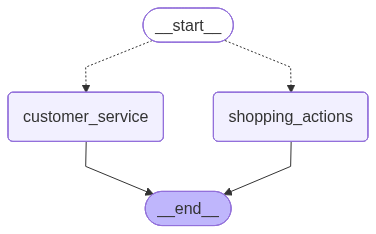

In [128]:
from langchain_core.runnables import router
from langgraph.graph import START, END, StateGraph

graph_builder = StateGraph(State)

graph_builder.add_conditional_edges(START, router_agent.run)

# graph_builder.add_node("shopping_actions", customer_service_agent.run)
graph_builder.add_node("shopping_actions", lambda x: x)
# graph_builder.add_node("product_search", product_search_agent.run)
graph_builder.add_node("customer_service", lambda x: x)

graph = graph_builder.compile()

graph